In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np

In [32]:

# Load the dataset
data = pd.read_csv('sample_v10.csv')
# print('Null values count by column :\n', data.isnull().sum())
# data.describe()

# Stratified split
train, test = train_test_split(
    data,
    test_size=0.3,
    stratify=data['y'],
    random_state=20231225
)

# Number of observations
train_count = len(train)
test_count = len(test)

# Relative frequencies of target category (rounded to 2 digits)
original_freq = data['y'].value_counts(normalize=True).round(2)
train_freq = train['y'].value_counts(normalize=True).round(2)
test_freq = test['y'].value_counts(normalize=True).round(2)

print(f"Training partition: {train_count} observations")
print(f"Testing partition: {test_count} observations")
print("Relative frequencies in Original data:")
print(original_freq)
print("Relative frequencies in Training partition:")
print(train_freq)
print("Relative frequencies in Testing partition:")
print(test_freq)


X_train = train.iloc[:, :10]
y_train = train['y']
X_test = test.iloc[:, :10]
y_test = test['y']

Training partition: 19259 observations
Testing partition: 8254 observations
Relative frequencies in Original data:
y
Bicycle    0.27
Walk       0.23
Taxi       0.23
Bus        0.14
Others     0.13
Name: proportion, dtype: float64
Relative frequencies in Training partition:
y
Bicycle    0.27
Walk       0.23
Taxi       0.23
Bus        0.14
Others     0.13
Name: proportion, dtype: float64
Relative frequencies in Testing partition:
y
Bicycle    0.27
Walk       0.23
Taxi       0.23
Bus        0.14
Others     0.13
Name: proportion, dtype: float64


In [37]:

def predict_with_tiebreak(clf, X, y_true=None):
    probs = clf.predict_proba(X)
    classes = clf.classes_
    preds = []
    tie_info = []
    for idx, row in enumerate(probs):
        max_prob = np.max(row)
        max_indices = np.where(row == max_prob)[0]
        if len(max_indices) > 1:
            # Tie: choose lexically lowest class
            tied_labels = [classes[i] for i in max_indices]
            chosen = sorted(tied_labels)[0]
            actual_label = y_true.iloc[idx] if y_true is not None else None
            tie_info.append({
                'index': idx,
                'tied_labels': tied_labels,
                'chosen_label': chosen,
                'actual_label': actual_label
            })
        else:
            chosen = classes[max_indices[0]]
        preds.append(chosen)
    return np.array(preds), tie_info


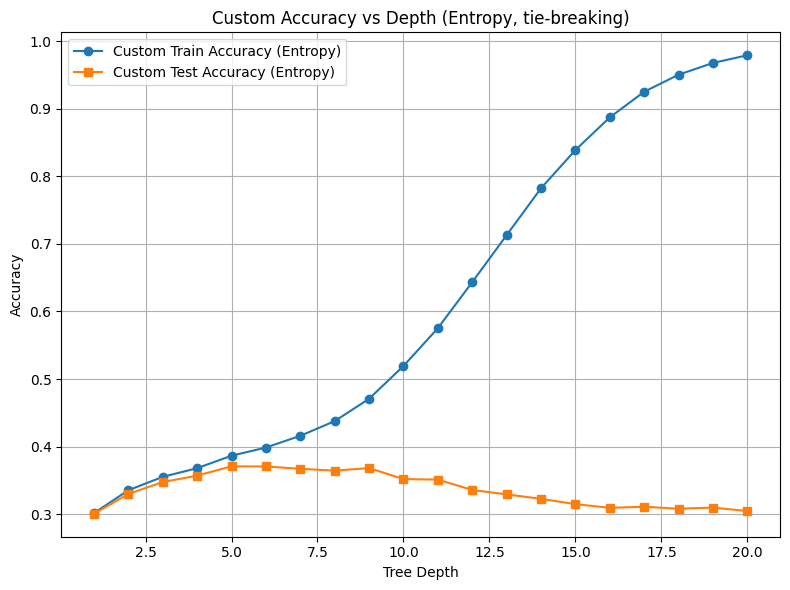

Best depth based on custom test accuracy (Entropy): 5
Class names: ['Bicycle' 'Bus' 'Others' 'Taxi' 'Walk']


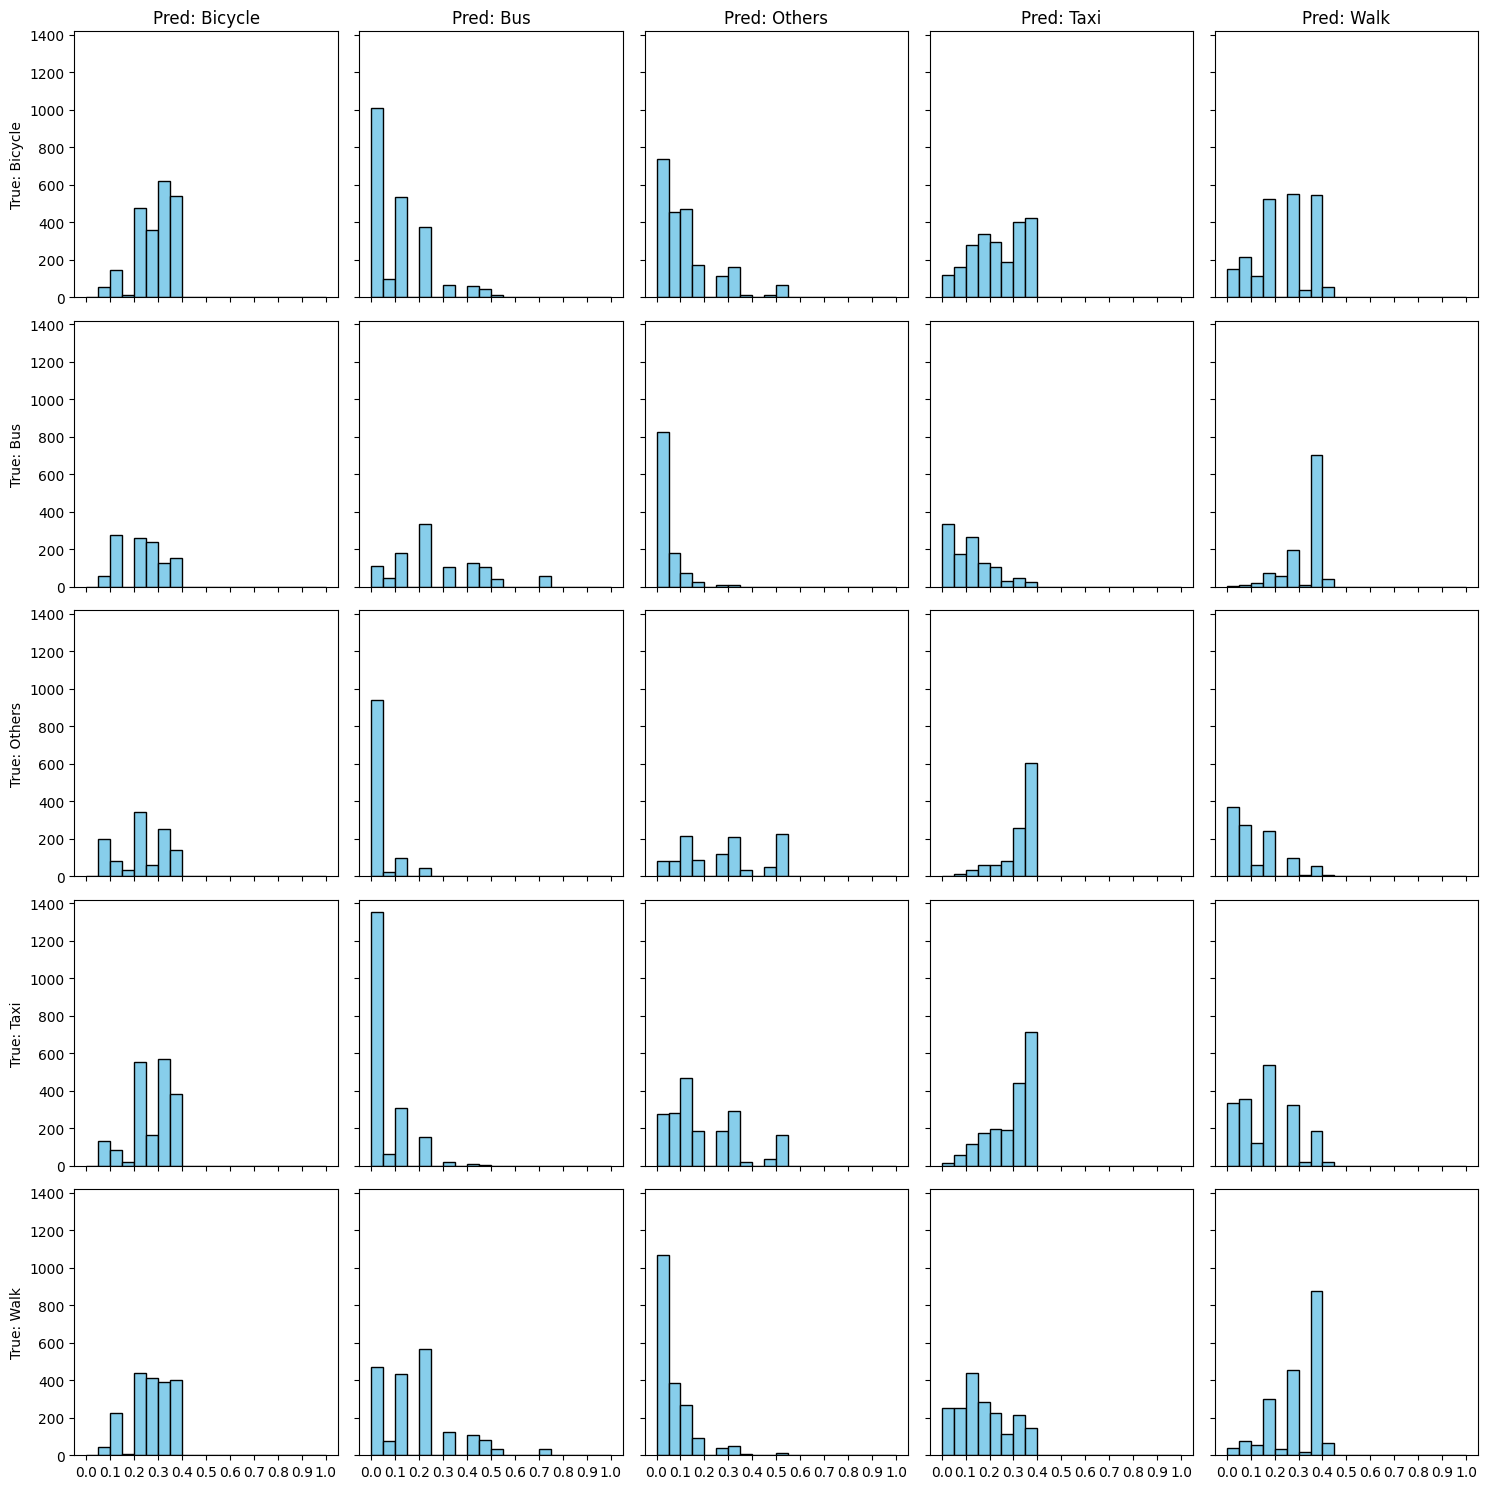

In [38]:


# Features and target
depths = range(1, 21)

# Initialize accuracy lists
custom_test_acc_entropy = []
custom_train_acc_entropy = []

for depth in depths:
    clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=20231225)
    clf_entropy.fit(X_train, y_train)

    y_pred_entropy, y_test_tie = predict_with_tiebreak(clf_entropy, X_test, y_test)

    acc_entropy = np.mean(y_pred_entropy == y_test)
    custom_test_acc_entropy.append(acc_entropy)
    y_pred_entropy_train, y_train_tie = predict_with_tiebreak(clf_entropy, X_train, y_train)
    acc_entropy_train = np.mean(y_pred_entropy_train == y_train)
    custom_train_acc_entropy.append(acc_entropy_train)

# Plot custom test and train accuracy for Entropy
plt.figure(figsize=(8, 6))
plt.plot(depths, custom_train_acc_entropy, label='Custom Train Accuracy (Entropy)', marker='o')
plt.plot(depths, custom_test_acc_entropy, label='Custom Test Accuracy (Entropy)', marker='s')
plt.title('Custom Accuracy vs Depth (Entropy, tie-breaking)')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# select the best depth based on test accuracy
best_depth_entropy = depths[np.argmax(custom_test_acc_entropy)]
print(f"Best depth based on custom test accuracy (Entropy): {best_depth_entropy}")

# Choose tree depth (example: 5, change as needed)
chosen_depth = best_depth_entropy

# Retrain decision tree
clf = DecisionTreeClassifier(criterion='entropy', max_depth=chosen_depth, random_state=20231225)
clf.fit(X_train, y_train)

# Calculate predicted probabilities for test set
probs = clf.predict_proba(X_test)
class_names = clf.classes_
print("Class names:", class_names)

import matplotlib.pyplot as plt

# Prepare 5x5 matrix of histograms
fig, axes = plt.subplots(5, 5, figsize=(15, 15), sharex=True, sharey=True)
bins = np.arange(0, 1.05, 0.05)

for i, true_label in enumerate(class_names):
    mask = y_test == true_label
    for j, pred_label in enumerate(class_names):
        ax = axes[i, j]
        ax.hist(probs[mask, j], bins=bins, color='skyblue', edgecolor='black')
        ax.set_xticks(np.arange(0, 1.1, 0.1))
        if i == 0:
            ax.set_title(f'Pred: {pred_label}')
        if j == 0:
            ax.set_ylabel(f'True: {true_label}')

plt.tight_layout()
plt.show()


In [40]:
len(y_test_tie)
len(y_train_tie)
# print("Tie-breaking info for test set:")
# for info in y_test_tie:
#     print(info) 

print("Tie-breaking info for train set:")
for info in y_train_tie:
    print(info) 

Tie-breaking info for train set:
{'index': 24, 'tied_labels': ['Bicycle', 'Taxi'], 'chosen_label': 'Bicycle', 'actual_label': 'Others'}
{'index': 727, 'tied_labels': ['Bicycle', 'Taxi'], 'chosen_label': 'Bicycle', 'actual_label': 'Bicycle'}
{'index': 825, 'tied_labels': ['Bicycle', 'Taxi'], 'chosen_label': 'Bicycle', 'actual_label': 'Taxi'}
{'index': 996, 'tied_labels': ['Bicycle', 'Others'], 'chosen_label': 'Bicycle', 'actual_label': 'Others'}
{'index': 1116, 'tied_labels': ['Others', 'Walk'], 'chosen_label': 'Others', 'actual_label': 'Others'}
{'index': 1221, 'tied_labels': ['Bicycle', 'Others'], 'chosen_label': 'Bicycle', 'actual_label': 'Bicycle'}
{'index': 1326, 'tied_labels': ['Bicycle', 'Taxi'], 'chosen_label': 'Bicycle', 'actual_label': 'Taxi'}
{'index': 1472, 'tied_labels': ['Bicycle', 'Taxi'], 'chosen_label': 'Bicycle', 'actual_label': 'Bicycle'}
{'index': 1748, 'tied_labels': ['Bicycle', 'Others'], 'chosen_label': 'Bicycle', 'actual_label': 'Bicycle'}
{'index': 1958, 'tied_l